### Scenario 3: Modified Montúfar Example 2 (Unequal Hyperrectangles)

In this example, we modify the Montúfar Linear Regions experiment in another way, so that we have unequal hyperrectangles in the input space. The biases in the original Montúfar example are equally spaced along each axis, so by modifying the spacing we can modify the linear region sizes.

#### Imports:

In [432]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import scipy.stats.qmc as qmc
from pathlib import Path
from itertools import groupby

#### Figure Settings

In [433]:
plt.rcParams.update(
    {
        "axes.labelsize": 13, 
        "xtick.labelsize": 13, 
        "ytick.labelsize": 13, 
        "legend.fontsize": 13, 
    }
)

#### Functions to generate/load point sets:

In [434]:
def iid_uniform_sample(num_points,dimensions,runs,lower_bounds, upper_bounds, rng):
    """Generates several iid uniform sample of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        rng: the pseudo-random number generator used to create the sample 
    Returns:
        points: 3D array of shape (runs,num_points,dimensions) representing all the points across all the samples
    """
    
    # Generate points in [0,1)^d
    points = rng.uniform(size=(runs,num_points,dimensions))
    
    # Map points to desired rectangular region
    points = lower_bounds + (upper_bounds - lower_bounds)*points

    # Map to torch tensor
    points = torch.tensor(points)
    
    return points

In [435]:
def halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,rng):
    """Generates several halton samples of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        rng: the pseudo-random number generator used to create the sample
    Returns:
        points: 3D array of shape (runs, num_points, dimensions)
    """

    points = np.empty((runs,num_points,dimensions))
    
    # You can use the same rng for all the runs because the state will evolve every time you call qmc.Halton() again
    for i in range(runs):
        sampler = qmc.Halton(d=dimensions,scramble=True,seed=rng)
        points[i,:,:] = sampler.random(num_points)

    points = points*(upper_bounds - lower_bounds) + lower_bounds

    # Convert to torch tensor for neural network processing
    points = torch.tensor(points)
    
    return points

In [436]:
def sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds,rng):
    """Generates several sobol samples of points with different sample sizes
    Args:
        sample_sizes: a list of sample sizes to use for the region counting
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        seed: the pseudo-random number generator used to create the sample
    Returns:
        all_points: a list of 3D arrays of shape (runs, num_points, dimensions)
    """

    all_points = []

    for i in range(len(sample_sizes)):
        
        points = np.empty((runs,sample_sizes[i],dimensions))
        
        for j in range(runs):
            
            sampler = qmc.Sobol(d=dimensions,scramble=True,seed=rng)
            points[j,:,:] = sampler.random(sample_sizes[i])

        points = points*(upper_bounds - lower_bounds) + lower_bounds

        # Convert to torch tensor so we can put through the neural network
        points = torch.tensor(points)
        
        all_points.append(points)

    return all_points

In [437]:
def load_blue_noise_points(path, lower_bound, upper_bound):
    """Formats the blue noise point sets in a way that they can be used for the experiments
    Args:
        path: location where the blue noise point sets are stored
        lower_bounds: lower bound for all dimensions to adjust blue noise point sets from [0,1]^d
        upper_bounds: upper bound for all dimensions to adjust blue noise point sets from [0,1]^d
    Returns:
        blue_noise_sets: a list of lists containing the blue noise points for each dimension
                         and sample size within that dimension
    """

    dir_path = Path(path)

    def get_metadata(path_obj):
        parts = path_obj.stem.split('_')
        return int(parts[3]),int(parts[2])

    sorted_file_paths = sorted(dir_path.glob('*.npy'),key=get_metadata)

    blue_noise_sets = []

    for dimension, group in groupby(sorted_file_paths, key = lambda p: get_metadata(p)[0]):
        lower_bounds = np.full(dimension,lower_bound)
        upper_bounds = np.full(dimension,upper_bound)
        sublist_data = []
        for file_path in group:
            point_set = lower_bounds + np.load(str(file_path),mmap_mode="r")*(upper_bounds-lower_bounds)
            point_set = torch.tensor(point_set)
            sublist_data.append(point_set)
        blue_noise_sets.append(sublist_data)

    return blue_noise_sets

In [438]:
def grid_sample(sample_sizes, dimensions, lower_bound, upper_bound):
    """Generates a sample of n=m^d points in a regular lattice
    Args:
        sample sizes: a list of values of m (the number of points on each axis to construct the grid)
        dimensions: d (the number of dimensions of the input space)
        lower_bound: the lower bound of the input space in each dimension
        upper_bound: the upper bound of the input space in each dimension
    Returns:
        grid_sample: the grid of points
    """

    samples = []

    for points_per_axis in sample_sizes:

        # Exclude the endpoint along each axis because we are looking at the number of regions in [0,1)^d with 1 excluded
        coordinate_arrays = [np.linspace(lower_bound,upper_bound,int(points_per_axis)) for i in range(dimensions)]
        meshes = np.meshgrid(*coordinate_arrays,indexing="ij")
        grid_sample = np.column_stack([m.ravel() for m in meshes])
        grid_sample = torch.tensor(grid_sample)
        grid_sample = torch.unsqueeze(grid_sample,dim=0)

        samples.append(grid_sample)

    return samples

#### Code to set up MLP

In [439]:
class MLP(torch.nn.Module):
    def __init__(self,dimensions,neurons_per_hidden,custom_weights=None,custom_biases=None):
        """Set up the neural network model according to the specification given by parameters
        Args:
            dimensions: number of input dimensions
            neurons_per_hidden: 1D array or list containing widths of each layer
            custom_weights: None if Kaiming normal initialisation is to be used, otherwise a list of 2D torch tensors,
                            representing weight matrices to be used between each adjacent pair of layers
            custom_biases: None if Kaiming normal initialisation is to be used, otherwise a list of 1D torch tensors,
                            representing the bias of each neuron in each layer of the neural network
        """
        super().__init__()

        # Create a PyTorch list to store the layers and store the number of neurons per layer
        self.layers = torch.nn.ModuleList()
        self.architecture = neurons_per_hidden

        # Create first hidden layer using dimensions parameter
        hidden1 = torch.nn.Linear(dimensions, neurons_per_hidden[0], bias=True)
        self.layers.append(hidden1)
        self.layers.append(torch.nn.ReLU())
        
        # Create the remaining hidden layers
        for i in range(len(neurons_per_hidden)-1):
            hidden = torch.nn.Linear(neurons_per_hidden[i], neurons_per_hidden[i+1], bias=True)
            self.layers.append(hidden)
            self.layers.append(torch.nn.ReLU())

        # Set initial weights for all layers using user-input or Kaiming normal initialisation
        if custom_weights:
            with torch.no_grad():
                for i in range(len(self.layers)):
                    if isinstance(self.layers[i],torch.nn.Linear):
                        self.layers[i].weight.copy_(custom_weights[int(i/2)])
                        self.layers[i].bias.copy_(custom_biases[int(i/2)])
        else:
            generator = torch.Generator()
            generator.manual_seed(1)
            self.apply(lambda m: self.init_weights(m,generator))

    def init_weights(self, module, generator):
        """Initialise weights according to Kaiming normal distribution and biases according to a uniform distribution
        Args:
            module: the layer to be initialised
            generator: sets a random seed to ensure reproducibility of initial weights
        """
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity="relu",generator=generator)
            torch.nn.init.uniform_(module.bias,a=-1.0,b=1,generator=generator)

    
    def forward(self,x):
        """Forward pass through the network to get the activations of each layer for a batch of data
        Args:
            x: a batch of inputs - 3D array of inputs of shape (number of runs, number of points, input dimension)
        Returns:
            activations: the activations of each neuron in each layer of the network,
                         as a 3D array of shape: (number of runs, number of points, total number of neurons)
        """
        x = x.float()
        for layer in self.layers:
            x = layer(x)
            # The layers are Linear, ReLU, Linear, ReLU, etc. Store activations after ReLU layers (>0 if on, =0 if off)
            if isinstance(layer,torch.nn.ReLU):
                # If we do not have the first layer, concatenate the activations along the last axis
                try:
                    activations = torch.cat((activations,x),axis=-1)
                # If we have the first layer, initialise the activations array
                except:
                    activations = x
        return activations

#### Code to count linear regions

Online region counting function which uses subsets of a larger sample (for Binomial Point Process/Halton Sequence):

In [440]:
def region_count_online(input_points,model,return_samples=False):
    """Count the number of unique linear regions in the input space of a MLP using a set of points distributed across the input space
    Args:
        points: torch tensor of points with shape (number of runs, number of points, dimensions)
        model: the neural network model we are analysing
        return_samples: Boolean flag telling you whether or not to return the samples corresponding with each region
    Returns:
        unique_counts: the number of regions counted using the sample points
        samples_by_region: a dictionary containing each unique region and the samples corresponding to it (or empty if return_samples=False)
    """

    # Set torch tensor for the number of regions counted in each run
    unique_counts = torch.zeros((input_points.shape[0],input_points.shape[1]))

    # Get array of activations with shape (number of runs, number of points, total number of neurons)
    activations = model(input_points)
    # For all the activations that are greater than 0, set the state to 1
    states = torch.zeros(activations.shape)
    states[activations>0] = 1
    states = states.to(torch.int64)
    
    # Get activation pattern by representing each series of activations as a base 2 number and converting to base 10
    cols = states.shape[-1]
    powers = 1 << torch.arange(cols - 1, -1, -1,dtype=torch.int64)
    activation_patterns = (states * powers).sum(dim=-1)

    # COUNT NUMBER OF UNIQUE REGIONS

    # Sort the activation patterns and get corresponding indices (stable = True ensures the first occurance is put first)
    sorted_t, indices = torch.sort(activation_patterns, dim=1, stable=True)
    
    # Find the first occurance of each new activation pattern as a Boolean Mask
    is_first_sorted = torch.ones_like(activation_patterns, dtype=torch.bool)
    is_first_sorted[:, 1:] = sorted_t[:, 1:] != sorted_t[:, :-1]
    
    # Put the true and false values back in their original order
    is_first_chronological = torch.empty_like(is_first_sorted)
    is_first_chronological.scatter_(dim=1, index=indices, src=is_first_sorted)
    
    # Count the number of true values up to each column using cumulative sum function in torch
    unique_counts = is_first_chronological.int().cumsum(dim=1)

    # GET ALL SAMPLES CORRESPONDING TO EACH REGION
    if return_samples:

        # Retrieve the unique patterns
        first_patterns = activation_patterns[0,:]
        unique_patterns = first_patterns[is_first_chronological[0,:]]
    
        samples_by_region = {}
        
        # Get the samples corresponding with each region
        for pattern in unique_patterns:
            input_points_first = input_points[0,:,:]
            samples_by_region[pattern] = input_points_first[activation_patterns[0,:]==pattern]

    else:

        samples_by_region = {}

    return unique_counts, samples_by_region

Offline region counting function which uses separate sample sizes (for Sobol Sequence/Gaussian Blue Noise)

In [441]:
def region_count_offline(input_points_list,model,return_samples=False):
    """Count the number of unique linear regions in the input space of a MLP using a set of points distributed across the input space
    Args:
        input_points_list: list of torch tensors of points with shape (number of runs, number of points, dimensions)
        model: the neural network model we are analysing
        return_samples: Boolean flag telling you whether or not to return the samples corresponding with each region
    Returns:
        unique_counts: the number of regions counted using the sample points
        samples_by_region: a dictionary containing each unique region and the samples corresponding to it (or empty if return_samples=False)
    """

    # Set torch tensor for the number of regions counted in each run
    runs = input_points_list[0].shape[0]
    unique_counts = torch.zeros((runs,len(input_points_list)))

    for i in range(len(input_points_list)):

        input_points = input_points_list[i]

        # Get array of activations with shape (number of runs, number of points, total number of neurons)
        activations = model(input_points)
        # For all the activations that are greater than 0, set the state to 1
        states = torch.zeros(activations.shape)
        states[activations>0] = 1
        states = states.to(torch.int64)
        
        # Get activation pattern by representing each series of activations as a base 2 number and converting to base 10
        cols = states.shape[-1]
        powers = 1 << torch.arange(cols - 1, -1, -1,dtype=torch.int64)
        activation_patterns = (states * powers).sum(dim=-1)
    
        # COUNT NUMBER OF UNIQUE REGIONS
    
        sorted_t, _ = torch.sort(activation_patterns, dim=1)
        changes = sorted_t[:, 1:] != sorted_t[:, :-1]
        counts_sample_size = changes.sum(dim=1) + 1

        unique_counts[:,i] = counts_sample_size

    # GET ALL SAMPLES CORRESPONDING TO EACH REGION
    if return_samples:

        # Retrieve the unique patterns
        unique_patterns = torch.unique(activation_patterns[0,:])
    
        samples_by_region = {}
        
        # Get the samples corresponding with each region
        for pattern in unique_patterns:
            input_points_final_samples = input_points_list[-1][0,:,:]
            samples_by_region[pattern] = input_points_final_samples[activation_patterns[0,:]==pattern]

    else:

        samples_by_region = {}

    return unique_counts, samples_by_region

#### Scenario 3 Experiment Function

**Scenario 3:**
- neurons per hidden $= 24$
- dimensions $= 2,3,4,5,6,7,8,9,10$
- regions $= 144, 512, 1296, 1024, 4096, 2187, 6561, 512, 1024$

In [442]:
def scenario_3(sample_points,hidden_neurons,dimensions,runs=100,mode="online",return_samples=False):
    """Experiment for region counting using Montufar hypercubes example
    Args:
        sample_points: the sampling points used to count the regions - either numpy array (online counting) or list of arrays (offline)
        hidden_neurons: the number of neurons in the single hidden layer
        dimensions: the number of input dimensions
        runs: the number of times to rerun the experiment with different independent samples
        mode: whether to use the online/offline version of the region counting function
              online is used for BPP/Halton and offline for Sobol/Blue Noise
    Returns:
        unique_counts: 2D array of number of regions found after each number of samples for the different runs
    """

    p = int(np.floor(hidden_neurons/dimensions))
    
    # Set the network weights using p and dimension
    custom_weights = []
    for i in range(dimensions):
        segment_weights = [0 for i in range(dimensions)]
        segment_weights[i] = 1
        custom_weights += [segment_weights for _ in range(p)]
    custom_weights = [torch.tensor(custom_weights)]

    # Set the network biases so that we have a repeating pattern of small and large regions
    def generate_sequence(p):
        sequence = [0]
        for i in range(1,p):
            if i%2 == 1:
                # For every group of 2, make the first region 3 times bigger than the other in each axis
                value = -i/p - 1/(2*p)
            else:
                value = -i/p
            sequence.append(value)
        return sequence

    sequence = generate_sequence(p)
    custom_biases = [torch.tensor(np.tile(sequence, dimensions))]

    # Set up neural network - number of hidden neurons is p*n0 rather than hidden_neurons because the remainder neurons have weights
    # and biases set to 0 so they are essentially "dummy" neurons
    neurons_per_hidden = [p*dimensions]
    model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
    if mode == "online":
        unique_counts, samples_by_region = region_count_online(sample_points,model,return_samples=return_samples)
    else:
        unique_counts, samples_by_region = region_count_offline(sample_points,model,return_samples=return_samples)

    return unique_counts, samples_by_region

#### Visualise linear regions

Visualise the configuration of linear regions to make sure that the experiment function is doing what we think it should:

In [443]:
rng = np.random.default_rng(seed=1)

In [445]:
num_points = 50000
runs = 100
dimensions = 2
hidden_neurons = 24

# Generate point set
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,rng)

# Count linear region susing those point sets and assign to the appropriate part of iid_counts
unique_counts_2d,samples_by_region_2d = experiment_3a(sample_points,hidden_neurons,dimensions,runs,mode="online",return_samples=True)

Text(0, 0.5, 'y')

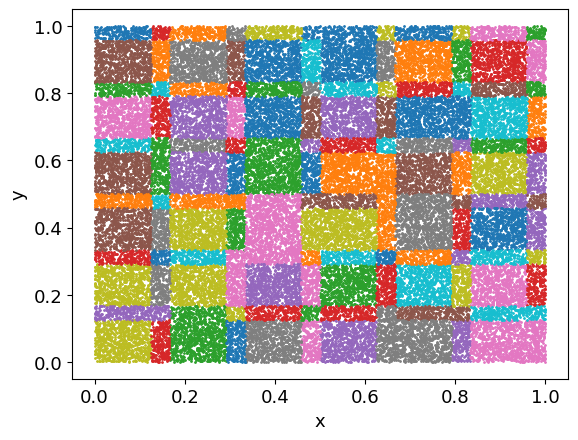

In [448]:
for key in samples_by_region_2d:
    plt.scatter(samples_by_region_2d[key][:,0],samples_by_region_2d[key][:,1],s=1)
plt.xlabel("x")
plt.ylabel("y")

Each axis is divided into segments of two different lengths, with the longer segment 3 times the shorter segment, which is what we wanted to set up.

#### Scenario 3

Set pseudo-random number generator for this experiment:

In [474]:
rng = np.random.default_rng(seed=1)

UNIFORM:

In [475]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
hidden_neurons = 24

iid_counts_3 = np.empty((max(all_dimensions)-1,runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,rng)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region = scenario_3(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    iid_counts_3[dimensions-2,:,:] = unique_counts

In [476]:
uniform_mean_3 = np.mean(iid_counts_3,axis=1)
uniform_variances_3 = np.var(iid_counts_3,axis=1)

Load uniform counts from first experiment for comparison:

In [477]:
iid_counts_1 = np.load('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_1/iid_counts_1.npy')

In [478]:
uniform_mean_1 = np.mean(iid_counts_1,axis=1)
uniform_variances_1 = np.var(iid_counts_1,axis=1)

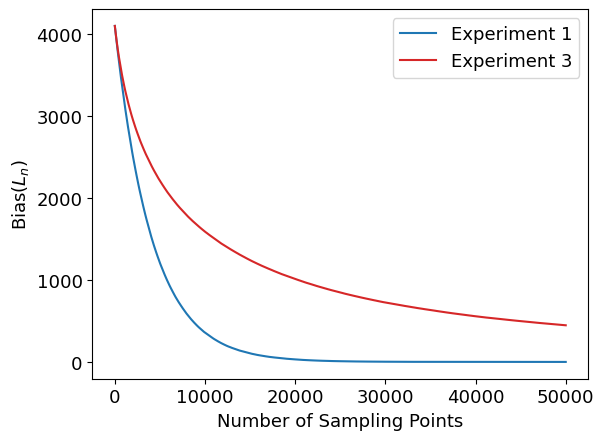

In [479]:
x = np.arange(50000)
plt.plot(x,4096-uniform_mean_1[4,:],label="Experiment 1")
plt.plot(x,4096-uniform_mean_3[4,:50000],label="Experiment 3",color="tab:red")
plt.xlabel("Number of Sampling Points")
plt.ylabel("Bias$(L_n)$")
plt.legend()

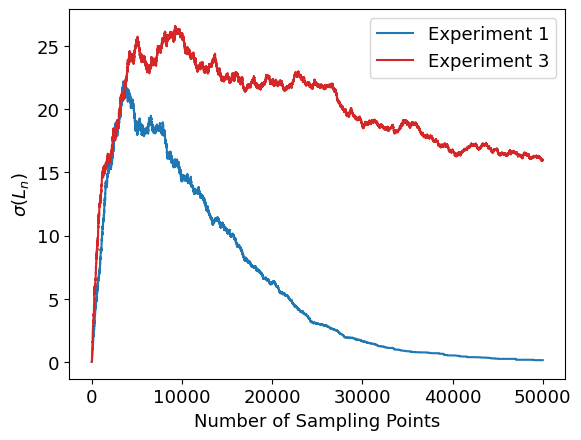

In [480]:
x = np.arange(50000)
plt.plot(x,np.sqrt(uniform_variances_1[4,:50000]),label="Experiment 1")
plt.plot(x,np.sqrt(uniform_variances_3[4,]),label="Experiment 3",color="tab:red")
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

2. Uniform/Halton/Sobol/Blue Noise/Grid Comparison Graphs

- Difference in region count between method and uniform against sample size for dimensions 2,4,6,8
- Standard deviation against sample size for dimensions 2,4,6,8

HALTON:

In [481]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
hidden_neurons = 24

halton_counts_3 = np.empty((max(all_dimensions)-1,runs,num_points))

for dimensions in all_dimensions:

    # Generate point sets
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,rng)

    # Count linear regions using those point sets and assign to the appropriate part of halton_counts_3
    unique_counts, samples_by_region = scenario_3(sample_points,hidden_neurons,dimensions,runs,mode="online",return_samples=False)
    unique_counts = unique_counts.detach().numpy()
    halton_counts_3[dimensions-2,:,:] = unique_counts

SOBOL:

In [482]:
all_dimensions = [2,3,4,5,6,7,8,9,10]
sample_sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
runs = 100
hidden_neurons = 24

sobol_counts_3 = np.empty((max(all_dimensions)-1,runs,len(sample_sizes)))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds,rng)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = scenario_3(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    sobol_counts_3[dimensions-2,:,:] = unique_counts

BLUE NOISE:

In [483]:
hidden_neurons = 24
runs = 100
all_dimensions = [2,3,4,5,6,7,8,9,10]

# Load point sets and get them into the right format
path = '/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_points_100_runs'
lower_bound = 0
upper_bound = 1

blue_noise_sets = load_blue_noise_points(path,lower_bound,upper_bound)

blue_noise_counts_3 = np.empty((max(all_dimensions)-1,runs,len(blue_noise_sets[0])))

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = blue_noise_sets[dimensions-2]

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = scenario_3(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    blue_noise_counts_3[dimensions-2,:,:] = unique_counts

GRID:

In [484]:
hidden_neurons = 24
all_dimensions = [2,3,4,5,6,7,8,9,10]
# For each dimension, generate up to 50000 points in a regular grid 
points_per_axis = [np.arange(2,np.ceil(50000**(1/d))) for d in all_dimensions]
lower_bound = 1e-10
upper_bound = 1-1e-10

grid_counts_3 = []

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = points_per_axis[dimensions-2]
    grid_points = grid_sample(sample_points,dimensions,lower_bound,upper_bound)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = scenario_3(grid_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    grid_counts_3.append(unique_counts)

In [485]:
halton_mean_3 = np.mean(halton_counts_3,axis=1)
halton_variances_3 = np.var(halton_counts_3,axis=1)

In [486]:
sobol_mean_3 = np.mean(sobol_counts_3,axis=1)
sobol_variances_3 = np.var(sobol_counts_3,axis=1)

In [487]:
blue_noise_mean_3 = np.mean(blue_noise_counts_3,axis=1)
blue_noise_variances_3 = np.var(blue_noise_counts_3,axis=1)

In [488]:
sample_sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]

Bias Graphs:

2D:

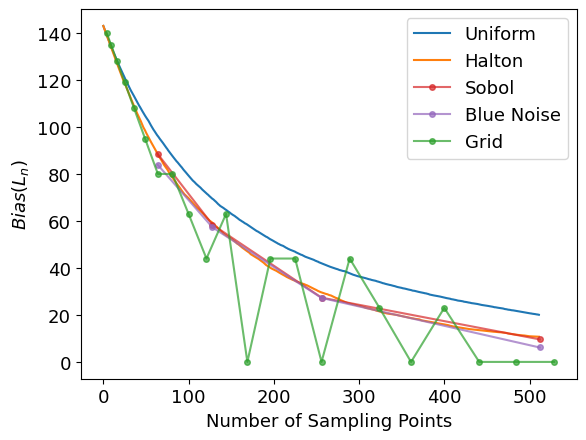

In [490]:
x = np.arange(512)
grid_sizes = [int(size) for size in points_per_axis[0][:22]**2]
plt.plot(x[:2**9],144-uniform_mean_3[0,:][:2**9],label="Uniform",color="tab:blue")
plt.plot(x[:2**9],144-halton_mean_3[0,:][:2**9],label="Halton",color="tab:orange")
plt.plot(sample_sizes[:4],144-sobol_mean_3[0,:][:4],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(sample_sizes[:4],144-blue_noise_mean_3[0,:][:4],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes,144-grid_counts_3[0][0][:22],
         alpha=0.7,color="tab:green",marker="o",label="Grid",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

4D:

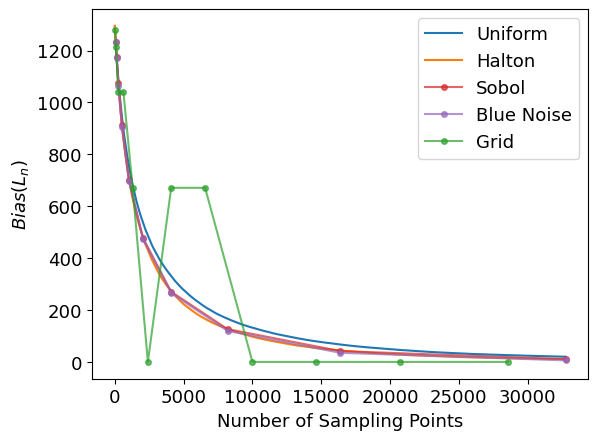

In [491]:
x = np.arange(50000)
grid_sizes = [int(size) for size in points_per_axis[2]**4][:-1]
plt.plot(x[:2**15],1296-uniform_mean_3[2,:][:2**15],label="Uniform")
plt.plot(x[:2**15],1296-halton_mean_3[2,:][:2**15],label="Halton",color="tab:orange")
plt.plot(sample_sizes[:10],1296-sobol_mean_3[2,:][:10],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(sample_sizes[:10],1296-blue_noise_mean_3[2,:][:10],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes,1296-grid_counts_3[2][0][:-1],color="tab:green",alpha=0.7,label="Grid",marker="o",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

6D:

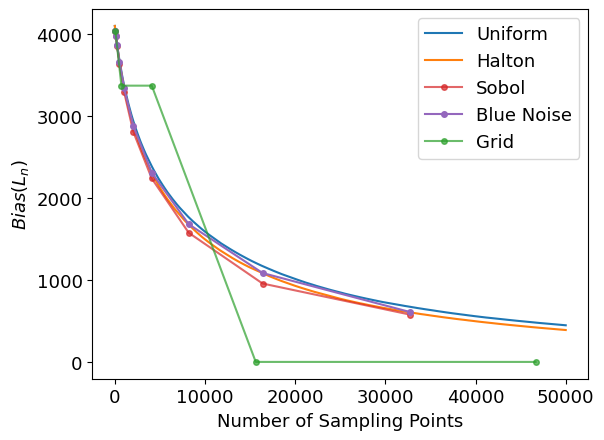

In [493]:
x = np.arange(50000)
grid_sizes = [int(size) for size in points_per_axis[4]**6]
plt.plot(x[:2**16],4096-uniform_mean_3[4,:][:2**16],label="Uniform")
plt.plot(x[:2**16],4096-halton_mean_3[4,:][:2**16],label="Halton")
plt.plot(sample_sizes[:11],4096-sobol_mean_3[4,:][:11],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(sample_sizes[:11],4096-blue_noise_mean_3[4,:][:11],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.plot(grid_sizes,4096-grid_counts_3[4][0],alpha=0.7,color="tab:green",label="Grid",marker="o",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

8D:

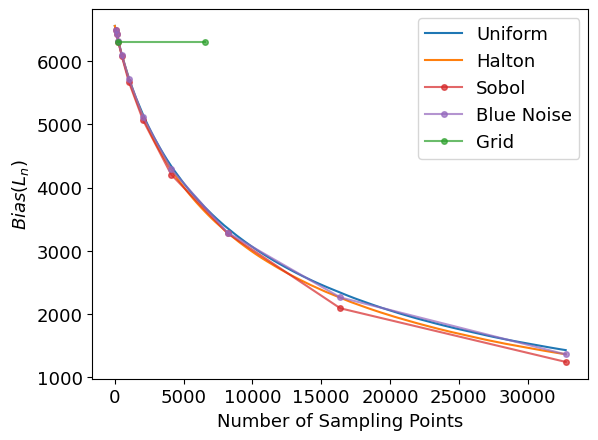

In [494]:
x = np.arange(50000)
grid_sizes = [int(size) for size in points_per_axis[6]**8]
plt.plot(x[:2**15],6561-uniform_mean_3[6,:][:2**15],label="Uniform")
plt.plot(x[:2**15],6561-halton_mean_3[6,:][:2**15],label="Halton",color="tab:orange")
plt.plot(sample_sizes[:10],6561-sobol_mean_3[6,:][:10],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sample_sizes[:10],6561-blue_noise_mean_3[6,:][:10],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes, 6561-grid_counts_3[6][0],alpha=0.7,color="tab:green",label="Grid",marker="o",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

Standard deviation graphs:

2D:

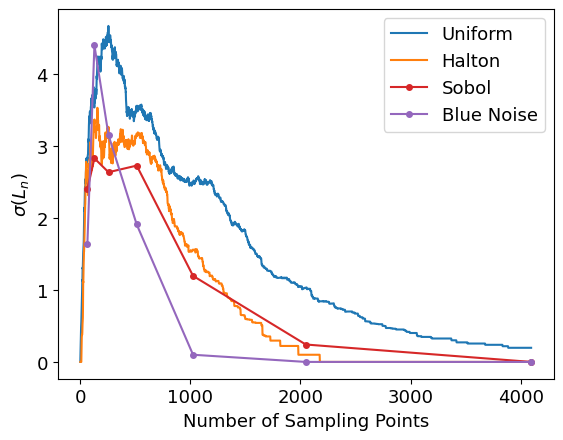

In [496]:
x = np.arange(50000)
plt.plot(x[:2**12],np.sqrt(uniform_variances_3[0,:][:2**12]),color="tab:blue",label="Uniform")
plt.plot(x[:2**12],np.sqrt(halton_variances_3[0,:][:2**12]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:7],np.sqrt(sobol_variances_3[0,:][:7]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(sample_sizes[:7],np.sqrt(blue_noise_variances_3[0,:][:7]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

4D:

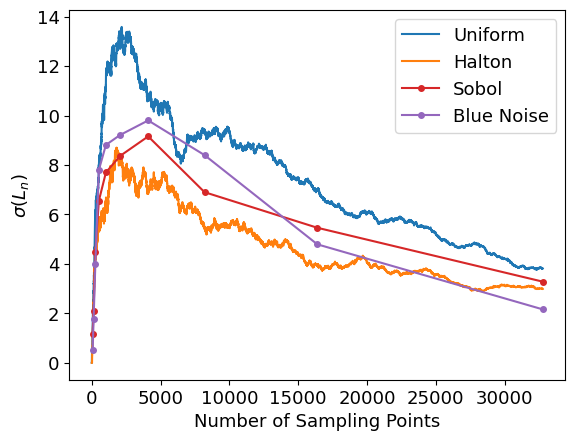

In [497]:
x = np.arange(50000)
plt.plot(x[:2**15],np.sqrt(uniform_variances_3[2,:][:2**15]),color="tab:blue",label="Uniform")
plt.plot(x[:2**15],np.sqrt(halton_variances_3[2,:][:2**15]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:10],np.sqrt(sobol_variances_3[2,:][:10]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(sample_sizes[:10],np.sqrt(blue_noise_variances_3[2,:][:10]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

6D:

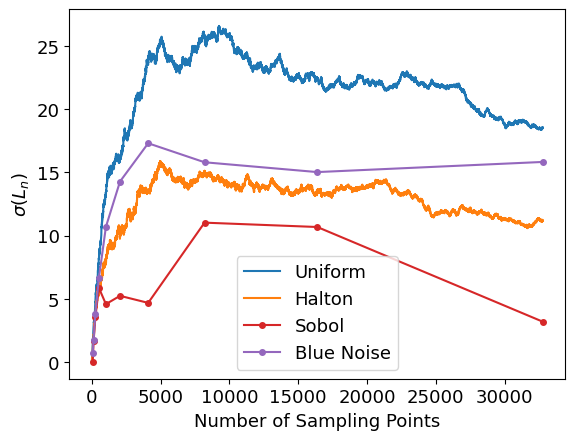

In [498]:
x = np.arange(50000)
plt.plot(x[:2**15],np.sqrt(uniform_variances_3[4,:][:2**15]),color="tab:blue",label="Uniform")
plt.plot(x[:2**15],np.sqrt(halton_variances_3[4,:][:2**15]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:10],np.sqrt(sobol_variances_3[4,:][:10]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(sample_sizes[:10],np.sqrt(blue_noise_variances_3[4,:][:10]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()
plt.tick_params()

8D:

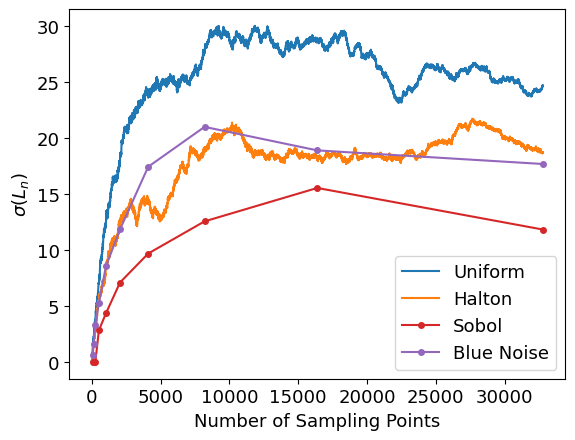

In [499]:
x = np.arange(50000)
plt.plot(x[:2**15],np.sqrt(uniform_variances_3[6,:][:2**15]),color="tab:blue",label="Uniform")
plt.plot(x[:2**15],np.sqrt(halton_variances_3[6,:][:2**15]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:10],np.sqrt(sobol_variances_3[6,:][:10]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(blue_noise_sample_sizes[:10],np.sqrt(blue_noise_variances_3[6,:][:10]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

#### Scenario 3B (not for MSc thesis)

We can modify the above example again so that the linear regions vary in size but the smaller ones are clumped together rather than being spread more evenly across space.

**N.B.** The following code has not been used for the MSc thesis, so may not work when the rest of the notebook is run.

In [223]:
def experiment_3b(sample_points,hidden_neurons,dimensions,runs=100,mode="online",return_samples=False):
    """Experiment for region counting using Montufar hypercubes example
    Args:
        sample_points: the sampling points used to count the regions - either numpy array (online counting) or list of arrays (offline)
        hidden_neurons: the number of neurons in the single hidden layer
        dimensions: the number of input dimensions
        runs: the number of times to rerun the experiment with different independent samples
        mode: whether to use the online/offline version of the region counting function
              online is used for BPP/Halton and offline for Sobol/Blue Noise
    Returns:
        unique_counts: 2D array of number of regions found after each number of samples for the different runs
    """

    p = int(np.floor(hidden_neurons/dimensions))
    
    # Set the network weights using p and dimension
    custom_weights = []
    for i in range(dimensions):
        segment_weights = [0 for i in range(dimensions)]
        segment_weights[i] = 1
        custom_weights += [segment_weights for _ in range(p)]
    custom_weights = [torch.tensor(custom_weights)]

    if p%2==0:
        custom_biases = [torch.tensor(np.tile([0] + [-0.5-0.5*i/p for i in range(int(-p/2)+1,int(p/2))], dimensions))]
    else:
        custom_biases = [torch.tensor(np.tile([0] + [-0.5-0.5*i/p for i in range(int(-p/2),0)] + [-0.5-0.5*i/p for i in range(1,int(p/2)+1)],
                                             dimensions))]

    # Set up neural network - number of hidden neurons is p*n0 rather than hidden_neurons because the remainder neurons have weights
    # and biases set to 0 so they are essentially "dummy" neurons
    neurons_per_hidden = [p*dimensions]
    model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
    if mode == "online":
        unique_counts, samples_by_region = region_count_online(sample_points,model,return_samples=return_samples)
    else:
        unique_counts, samples_by_region = region_count_offline(sample_points,model,return_samples=return_samples)

    return unique_counts, samples_by_region

See the graph of the shape of the regions:

In [234]:
num_points = 1000000
all_dimensions = [2]
runs = 100
seed = 1
hidden_neurons = 24

iid_counts_3b_visualisation = np.empty((max(all_dimensions)-1,runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region = experiment_3b(sample_points,hidden_neurons,dimensions,runs,mode="online",return_samples=True)
    unique_counts = unique_counts.detach().numpy()
    iid_counts_3b_visualisation[dimensions-2,:,:] = unique_counts

Text(0, 0.5, 'y')

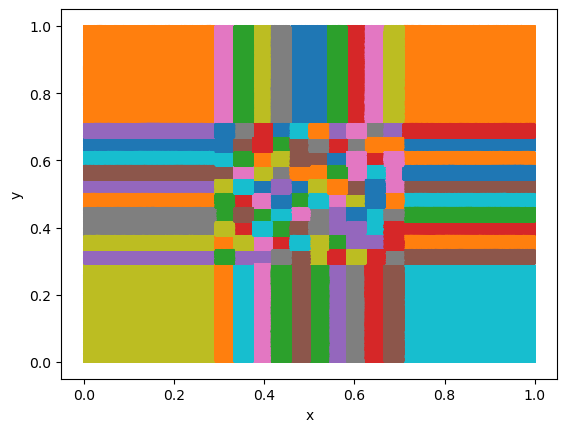

In [236]:
for key in samples_by_region.keys():
    plt.plot(samples_by_region[key][:,0],samples_by_region[key][:,1])
plt.xlabel("x")
plt.ylabel("y")

UNIFORM:

In [95]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8]
runs = 100
seed = 1
hidden_neurons = 24

iid_counts_3b = np.empty((max(all_dimensions)-1,runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region = experiment_3b(sample_points,hidden_neurons,dimensions,runs,mode="online",return_samples=False)
    unique_counts = unique_counts.detach().numpy()
    iid_counts_3b[dimensions-2,:,:] = unique_counts

In [96]:
uniform_mean_3b = np.mean(iid_counts_3b,axis=1)
uniform_variances_3b = np.var(iid_counts_3b,axis=1)

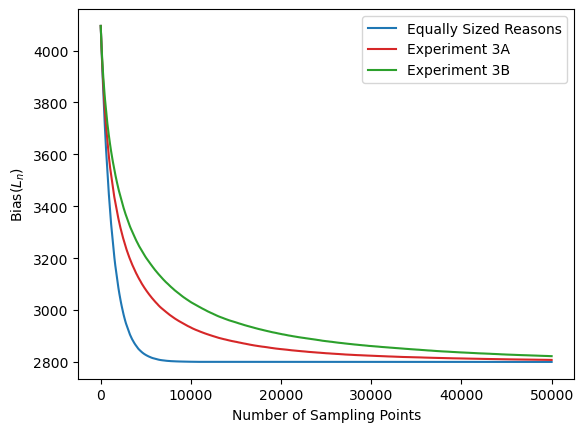

In [237]:
x = np.arange(50000)
plt.plot(x,4096-uniform_mean_prev[2,:],color="tab:blue",label="Equally Sized Reasons")
plt.plot(x,4096-uniform_mean_3a[2,:],color="tab:red",label="Experiment 3A")
plt.plot(x,4096-uniform_mean_3b[2,:],color="tab:green",label="Experiment 3B")
plt.xlabel("Number of Sampling Points")
plt.ylabel("Bias$(L_n)$")
plt.legend()

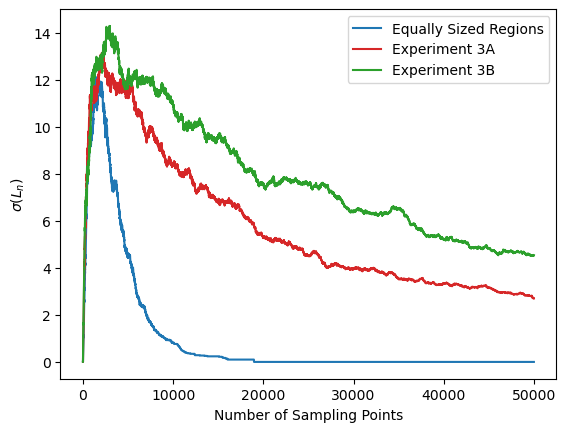

In [238]:
x = np.arange(50000)
plt.plot(x,np.sqrt(uniform_variances_prev[2,:50000]),label="Equally Sized Regions",color="tab:blue")
plt.plot(x,np.sqrt(uniform_variances_3a[2,:]),label="Experiment 3A",color="tab:red")
plt.plot(x,np.sqrt(uniform_variances_3b[2,:]),label="Experiment 3B",color="tab:green")
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

HALTON:

In [107]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8]
runs = 100
seed = 1
hidden_neurons = 24

halton_counts_3b = np.empty((max(all_dimensions)-1,runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region using those point sets 
    unique_counts, samples_by_region = experiment_3b(sample_points,hidden_neurons,dimensions,runs,mode="online",return_samples=False)
    unique_counts = unique_counts.detach().numpy()
    halton_counts_3b[dimensions-2,:,:] = unique_counts

SOBOL:

In [239]:
all_dimensions = [2,3,4,5,6,7,8]
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
runs = 100
hidden_neurons = 24
seed=1

sobol_counts_3b = np.empty((max(all_dimensions)-1,runs,len(sample_sizes)))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region using those point sets
    unique_counts, samples_by_region = experiment_3b(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    sobol_counts_3b[dimensions-2,:,:] = unique_counts

BLUE NOISE:

In [111]:
hidden_neurons = 24
runs = 100
all_dimensions = [2,3,4,5,6,7,8]

# Load point sets and get them into the right format
path = '/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_points_100_runs'
lower_bound = 0
upper_bound = 1

blue_noise_sets = load_blue_noise_points(path,lower_bound,upper_bound)

blue_noise_counts_3b = np.empty((max(all_dimensions)-1,runs,len(blue_noise_sets[0])))

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = blue_noise_sets[dimensions-2]

    # Count linear region using those point sets
    unique_counts, samples_by_region = experiment_3b(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    blue_noise_counts_3b[dimensions-2,:,:] = unique_counts

GRID:

In [158]:
hidden_neurons = 24
all_dimensions = [2,3,4,5,6,7,8]
# For each dimension, generate up to 50000 points in a regular grid 
points_per_axis = [np.arange(2,np.ceil(50000**(1/d))) for d in all_dimensions]
lower_bound = 1e-10
upper_bound = 1-1e-10

grid_counts_3b = []

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = points_per_axis[dimensions-2]
    grid_points = grid_sample(sample_points,dimensions,lower_bound,upper_bound)

    # Count linear region using those point sets
    unique_counts, samples_by_region = experiment_3b(grid_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    grid_counts_3b.append(unique_counts)

In [154]:
halton_mean_3b = np.mean(halton_counts_3b,axis=1)
halton_variances_3b = np.var(halton_counts_3b,axis=1)

In [240]:
sobol_mean_3b = np.mean(sobol_counts_3b,axis=1)
sobol_variances_3b = np.var(sobol_counts_3b,axis=1)

In [164]:
blue_noise_mean_3b = np.mean(blue_noise_counts_3b,axis=1)
blue_noise_variances_3b = np.var(blue_noise_counts_3b,axis=1)

In [162]:
sobol_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15, 2**16, 2**17]
blue_noise_sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]

Bias graphs:

2D:

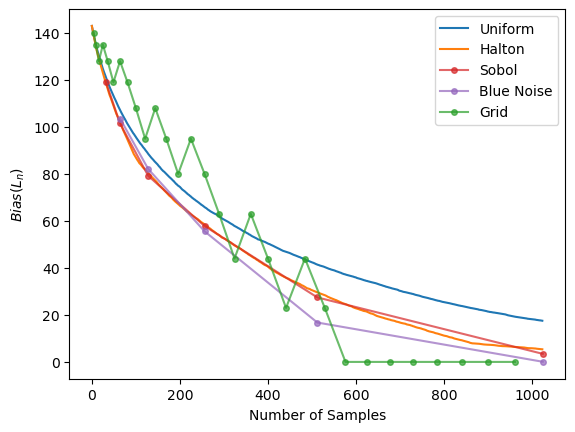

In [241]:
x = np.arange(1024)
grid_sizes = [int(size) for size in points_per_axis[0][:30]**2]
plt.plot(x[:2**10],144-uniform_mean_3b[0,:][:2**10],label="Uniform",color="tab:blue")
plt.plot(x[:2**10],144-halton_mean_3b[0,:][:2**10],label="Halton",color="tab:orange")
plt.plot(sample_sizes[:6],144-sobol_mean_3b[0,:][:6],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sizes[:5],144-blue_noise_mean_3b[0,:][:5],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes,144-grid_counts_3b[0][0][:30],
         alpha=0.7,color="tab:green",marker="o",label="Grid",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

4D:

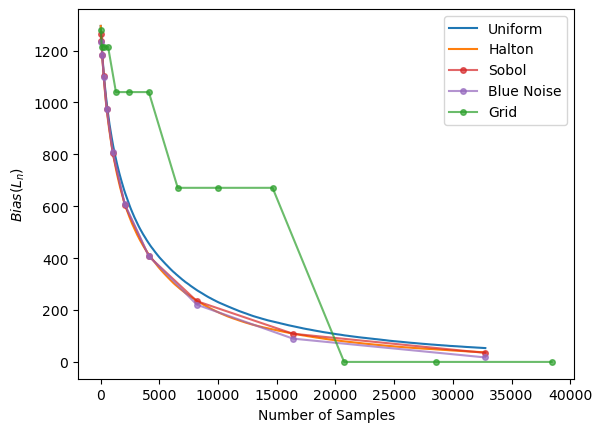

In [242]:
x = np.arange(2**15)
grid_sizes = [int(size) for size in points_per_axis[2][:30]**4]
plt.plot(x,1296-uniform_mean_3b[2,:][:2**15],label="Uniform",color="tab:blue")
plt.plot(x,1296-halton_mean_3b[2,:][:2**15],label="Halton",color="tab:orange")
plt.plot(sample_sizes,1296-sobol_mean_3b[2,:],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sizes,1296-blue_noise_mean_3b[2,:],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes,1296-grid_counts_3b[2][0][:30],
         alpha=0.7,color="tab:green",marker="o",label="Grid",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

6D:

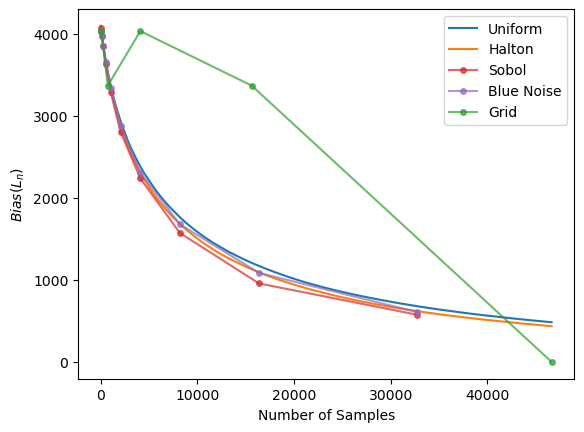

In [243]:
x = np.arange(50000)
grid_sizes = [int(size) for size in points_per_axis[4][:30]**6]
plt.plot(x[:grid_sizes[-1]],4096-uniform_mean_3b[4,:][:grid_sizes[-1]],label="Uniform",color="tab:blue")
plt.plot(x[:grid_sizes[-1]],4096-halton_mean_3b[4,:][:grid_sizes[-1]],label="Halton",color="tab:orange")
plt.plot(sample_sizes,4096-sobol_mean_3b[4,:],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sizes,4096-blue_noise_mean_3b[4,:],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes,4096-grid_counts_3b[4][0][:30],
         alpha=0.7,color="tab:green",marker="o",label="Grid",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

8D:

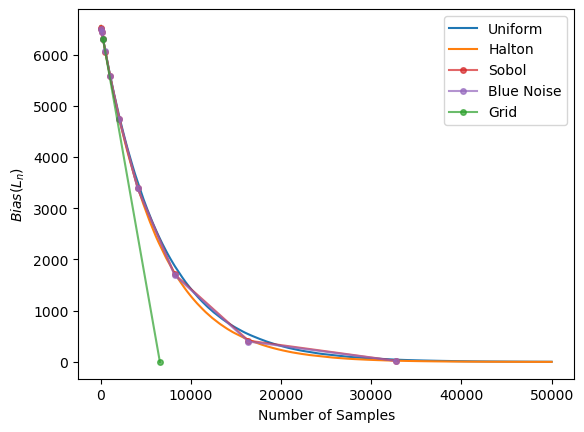

In [244]:
x = np.arange(50000)
grid_sizes = [int(size) for size in points_per_axis[6][:30]**8]
plt.plot(x,6561-uniform_mean_3b[6,:50000],label="Uniform",color="tab:blue")
plt.plot(x,6561-halton_mean_3b[6,:50000],label="Halton",color="tab:orange")
plt.plot(sample_sizes,6561-sobol_mean_3b[6,:],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sizes,6561-blue_noise_mean_3b[6,:],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes,6561-grid_counts_3b[6][0][:30],
         alpha=0.7,color="tab:green",marker="o",label="Grid",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

#### Save Experiment Data:

Experiment 3A:

In [500]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_3/iid_counts_3.npy',iid_counts_3)

In [501]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_3/halton_counts_3.npy',halton_counts_3)

In [502]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_3/sobol_counts_3.npy',sobol_counts_3)

In [503]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_3/blue_noise_counts_3.npy',blue_noise_counts_3)

In [504]:
np.savez('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_3/grid_counts_scenario_3.npz',*grid_counts_3)

Experiment 3B:

In [182]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_3/iid_counts_3b.npy',iid_counts_3b)

In [183]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_3/halton_counts_3b.npy',halton_counts_3b)

In [246]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_3/sobol_counts_3b.npy',sobol_counts_3b)

In [185]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_3/blue_noise_counts_3b.npy',blue_noise_counts_3b)

In [186]:
np.savez('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_3/grid_counts_scenario_3b.npz',*grid_counts_3b)

#### Demonstration of instability of grid method in integration

In [129]:
def step_function(x):
    y = np.ones(x.shape)
    y[x<0]=0
    y[x>1]=0
    return y

In [114]:
import scipy.integrate as integrate

In [133]:
x = np.linspace(-1,2,num=4)
y = step_function(x)
result = integrate.trapezoid(y,x)

In [137]:
integrals = []
for num_points in range(4,1000):
    x = np.linspace(-1,2,num_points)
    y = step_function(x)
    result = integrate.trapezoid(y,x)
    integrals.append(result)

Text(0, 0.5, 'Integral')

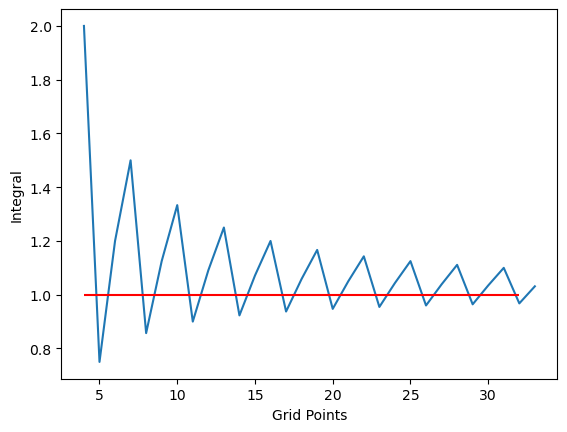

In [150]:
grid_sizes = np.arange(4,1000)
plt.plot(grid_sizes[:30],integrals[:30])
plt.hlines(1,4,32,color="red")
plt.xlabel("Grid Points")
plt.ylabel("Integral")

#### Simple Example of Delaunay Triangulation

The purpose of this code is to illustrate the idea of the algorithm presented in future work only.

In [388]:
from scipy.spatial import Delaunay
import matplotlib.tri as mtri

In [374]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [2]
runs = 1
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
custom_biases = [torch.tensor([0.0,0.0])]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = np.array([[[-0.5,-0.25],[-0.8,0.9],[0,0.25],[0.5,0.8]]])
unique_counts_delaunay, samples_by_region_delaunay = region_count_online(torch.tensor(points),model,return_samples=True)

In [375]:
vertices = np.array([[-1,-1],[-1,1],[1,-1],[1,1]])
all_points = np.concatenate((vertices,points[0,:,:]),axis=0)

In [376]:
triangulation = Delaunay(all_points)

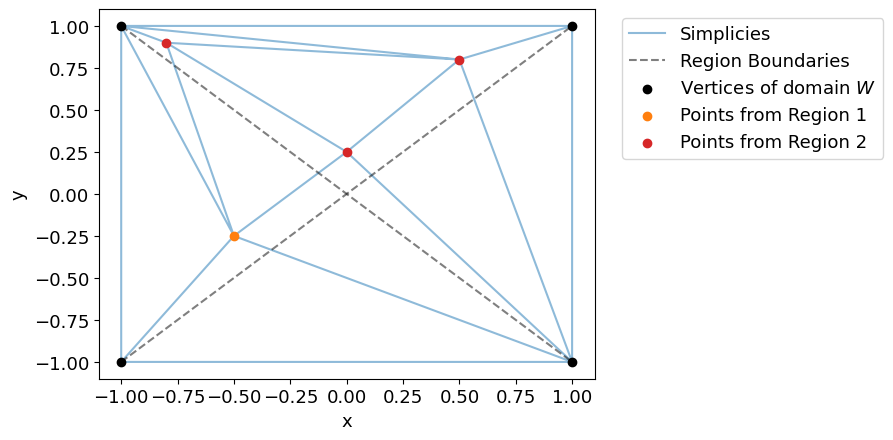

In [399]:
plt.triplot(all_points[:,0],all_points[:,1],triangulation.simplices,alpha=0.5,label="Simplicies")
a = np.linspace(-1,1,1000)
plt.plot(a,a,linestyle="--",color="black",alpha=0.5,label="Region Boundaries")
plt.plot(a,-a,linestyle="--",color="black",alpha=0.5)
plt.scatter(vertices[:,0],vertices[:,1],color="black",label="Vertices of domain $W$")
colours = ["tab:orange","tab:red","tab:green","tab:purple"]
i=1
for key in samples_by_region_delaunay.keys():
    plt.scatter(samples_by_region_delaunay[key][:,0],samples_by_region_delaunay[key][:,1],color=colours[i-1],label=f"Points from Region {i}")
    i+=1
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper right",bbox_to_anchor=(1.6,1))